# Instructions for the Coding Practice

---

Welcome to your coding practice! In this exercise, you will work with a dataset related to the **Rick and Morty** TV show. This coding practice is designed to test your data manipulation and analysis skills. Please follow the instructions below carefully:

1. **Understand the Dataset**: The dataset used in this coding practice is based on the Rick and Morty TV show. Take time to explore and understand its structure and contents before beginning the tasks.

2. **Read Each Question Thoroughly**: Each task is designed to assess specific data handling skills. Be sure to fully understand what each question is asking before you start working on your solution.

3. **Write Your Code in the Provided Cells**: For every question, a code cell is provided where you should enter your solution. Do not alter any other parts of the coding practice template.

4. **Execute Your Code**: After writing your code in each cell, run it to check whether the output matches the requirements. Make sure the results are correct and consistent with the instructions.

5. **Complete All Questions**: Be sure to answer every question included in the coding practice. Each one evaluates different concepts and techniques.

6. **Review Your Work**: Before final submission, carefully review your answers. Ensure that all code cells have been executed, outputs are accurate, and there are no errors in your notebook.

7. **Download Your Notebook**: Once you’ve finished and reviewed your work, download the notebook file (`.ipynb`). In Google Colab, this can be done via `File` > `Download` > `Download .ipynb`.

8. **Submit Your Coding Practice**: Upload the downloaded file to the appropriate platform designated for submissions.

9. **Verify Submission**: Double-check that the correct file was uploaded and that it opens properly. If something goes wrong, re-download and re-submit as necessary.

---

**Good luck with your Coding Practice!**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

character_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/characters_dataset.csv"
episodes_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/episodes_dataset.csv"
locations_data_url = "https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/locations_dataset.csv"

characters = pd.read_csv(character_data_url,index_col=0)
episodes = pd.read_csv(episodes_data_url,index_col=0)
locations = pd.read_csv(locations_data_url,index_col=0)

---
1. Which ten locations have the highest resident counts, and what are the resident_count values for each?

In [2]:
# Write your code here

locations['resident_count'] = locations['residents'].apply(lambda x: len(ast.literal_eval(x)))

# Get top 10 locations by resident count
top_locations = locations[['name', 'resident_count']].sort_values(by='resident_count', ascending=False).head(10)

# Print result
print(top_locations)

                             name  resident_count
19  Earth (Replacement Dimension)             230
2                Citadel of Ricks             101
5          Interdimensional Cable              62
0                   Earth (C-137)              27
12                       Nuptia 4              11
4                    Anatomy Park              11
7          Post-Apocalyptic Earth              10
3               Worldender's lair               9
15      St. Gloopy Noops Hospital               9
17         Mr. Goldenfold's dream               8


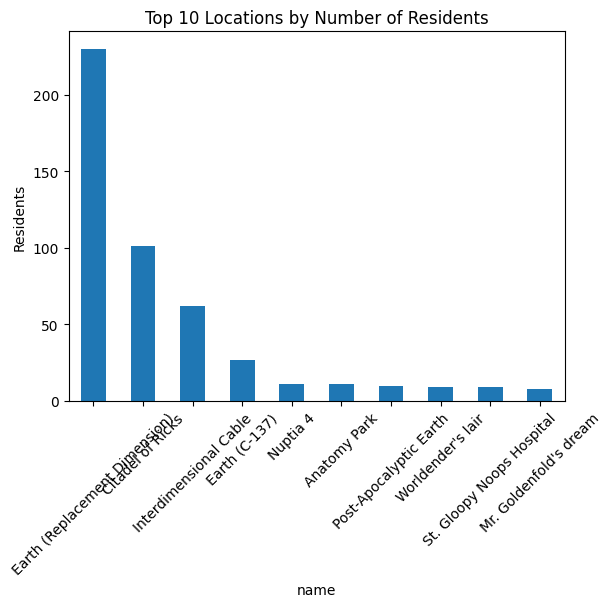

In [3]:
# Write your code here to visualize the data

top_locations.plot(kind='bar', x='name', y='resident_count', legend=False)
plt.title('Top 10 Locations by Number of Residents')
plt.ylabel('Residents')
plt.xticks(rotation=45)
plt.show()

---
2. Which three character origins appear most frequently, and what are their respective counts?

In [4]:
# Write your code here

characters['origin_name'] = characters['origin'].apply(eval).apply(lambda x: x['name'])
origin_counts = characters['origin_name'].value_counts().head(10).reset_index()
origin_counts.columns = ['origin', 'count']
print(origin_counts)

                          origin  count
0                        unknown     10
1  Earth (Replacement Dimension)      5
2                  Earth (C-137)      4
3                       Abadango      1


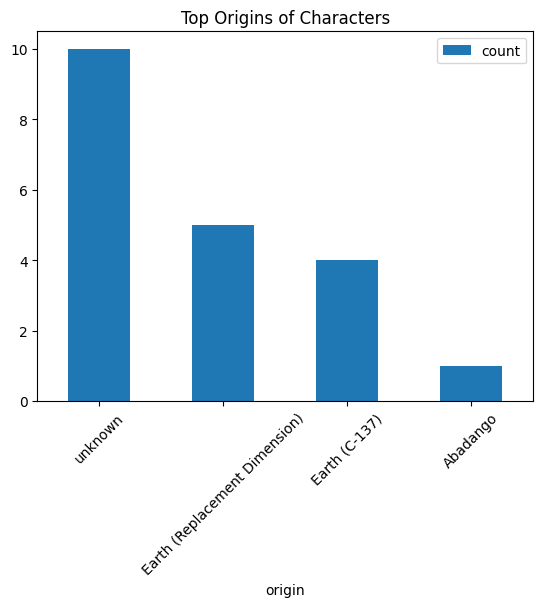

In [5]:
# Write your code here to visualize the data

origin_counts.plot(kind='bar', x='origin', y='count')
plt.title('Top Origins of Characters')
plt.xticks(rotation=45)
plt.show()

---
3. Which three dimensions contain the most locations, and what are their respective location_count values?

In [6]:
# Write your code here

dimension_counts = locations['dimension'].value_counts().reset_index()
dimension_counts.columns = ['dimension', 'location_count']
print(dimension_counts)

                    dimension  location_count
0                     unknown              10
1             Dimension C-137               3
2       Replacement Dimension               3
3  Post-Apocalyptic Dimension               1
4        Cronenberg Dimension               1
5           Fantasy Dimension               1
6             Dimension 5-126               1


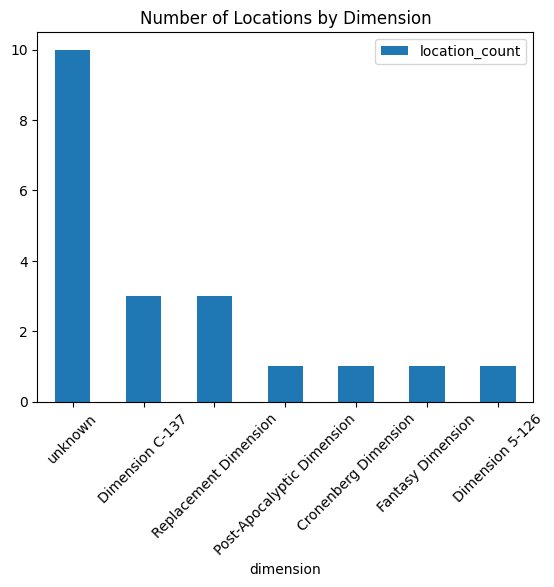

In [7]:
# Write your code here to visualize the data

dimension_counts.plot(kind='bar', x='dimension', y='location_count')
plt.title('Number of Locations by Dimension')
plt.xticks(rotation=45)
plt.show()

---
4. What is the breakdown of character counts by gender (female, male, genderless, unknown) for each of the top five species?

In [8]:
# Write your code here

top_species = characters['species'].value_counts().head(5).index
gender_species = characters[characters['species'].isin(top_species)]
gender_species_count = gender_species.groupby(['species', 'gender']).size().unstack(fill_value=0)
print(gender_species_count)

gender   Female  Male  unknown
species                       
Alien         1     3        1
Human         3    12        0


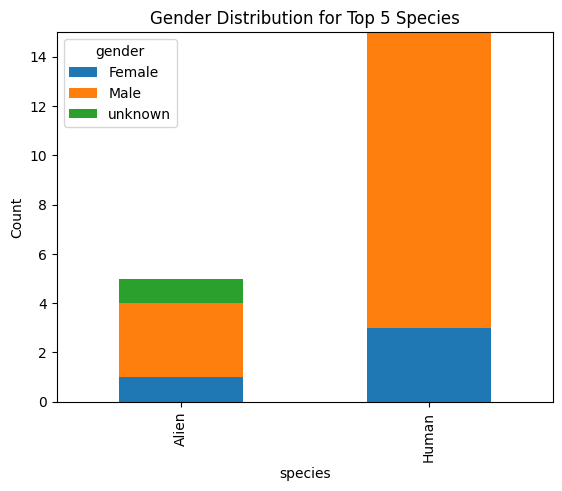

In [9]:
# Write your code here to visualize the data

gender_species_count.plot(kind='bar', stacked=True)
plt.title('Gender Distribution for Top 5 Species')
plt.ylabel('Count')
plt.show()

---
5. What are the counts for each gender category among the characters?

In [10]:
# Write your code here

gender_counts = characters['gender'].value_counts()
gender_counts.index.name = 'gender'
gender_counts.name = 'count'

print(gender_counts)

gender
Male       15
Female      4
unknown     1
Name: count, dtype: int64


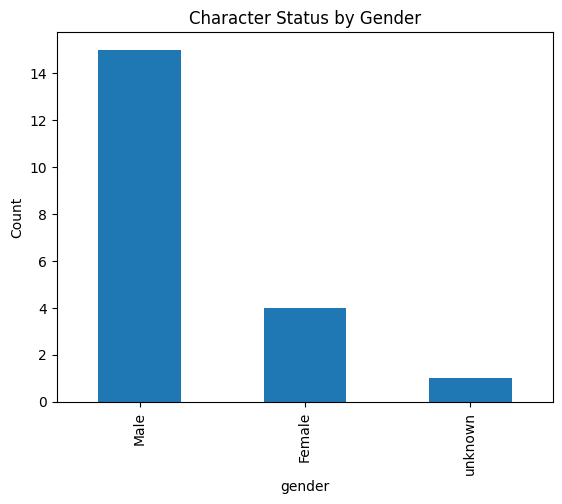

In [11]:
# Write your code here to visualize the data

gender_counts.plot(kind='bar', stacked=True)
plt.title('Character Status by Gender')
plt.ylabel('Count')
plt.show()

---
6. Which ten episodes feature the most characters, and what is the character count for each?

In [12]:
# Write your code here

episodes['character_count'] = episodes['characters'].apply(lambda x: len(eval(x)))
top_character_episodes = episodes[['name', 'character_count']].sort_values(by='character_count', ascending=False).head(10)

print(top_character_episodes)

                                       name  character_count
9      Close Rick-counters of the Rick Kind               60
7                             Rixty Minutes               57
18  Interdimensional Cable 2: Tempting Fate               40
12                           Mortynight Run               36
15                             Get Schwifty               31
10                          Ricksy Business               30
17            Big Trouble in Little Sanchez               26
2                              Anatomy Park               24
14                            Total Rickall               24
5                            Rick Potion #9               24


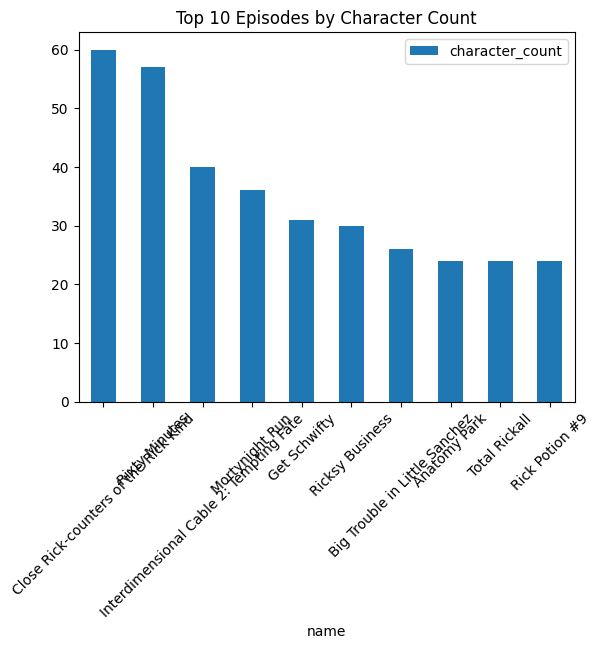

In [13]:
# Write your code here to visualize the data

top_character_episodes.plot(kind='bar', x='name', y='character_count')
plt.title('Top 10 Episodes by Character Count')
plt.xticks(rotation=45)
plt.show()

---
7. Which ten location types have the highest average resident counts, and what is the average resident_count for each?

In [14]:
# Write your code here

locations['resident_count'] = locations['residents'].apply(lambda x: len(eval(x)))
avg_residents = locations.groupby('type')['resident_count'].mean().sort_values(ascending=False).head(10).reset_index()
print(avg_residents)

            type  resident_count
0             TV       62.000000
1  Space station       55.000000
2         Planet       24.416667
3     Microverse       11.000000
4          Dream        8.000000
5   Fantasy town        3.000000
6         Resort        3.000000
7        Cluster        1.000000


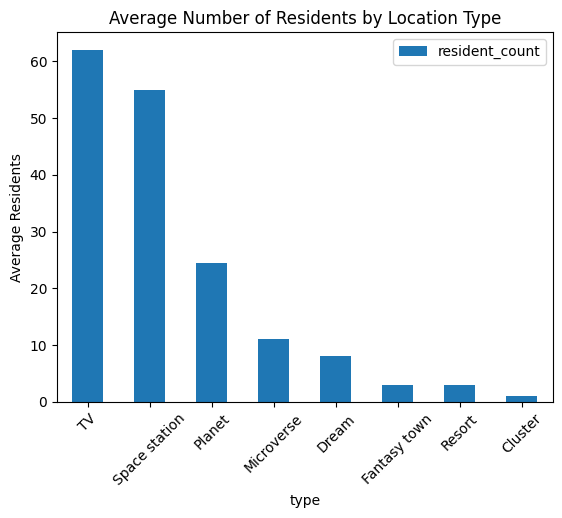

In [15]:
# Write your code here to visualize the data

avg_residents.plot(kind='bar', x='type', y='resident_count')
plt.title('Average Number of Residents by Location Type')
plt.ylabel('Average Residents')
plt.xticks(rotation=45)
plt.show()

# END